In [10]:
# import libraries

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

import os

Import files

In [11]:
# Load total pop
total_pop_folder = "Population Data"
pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_age_breakdown.parquet"))

# Load student pop
student_pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_stu_breakdown.parquet"))

# Load school pop
school_folder = "School Data"
school_gdf = gpd.read_parquet(os.path.join(school_folder, "swk_list_of_schools_2025.parquet"))

# Load combined routes
routes_folder = "OSRM Routes to Nearest School"
secondary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "secondary_combined_routes.parquet"))
primary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "primary_combined_routes.parquet"))

# Load aggregated data
aggregated_data_folder = "Aggregated Data"
district_time_stats_df = pd.read_csv(os.path.join(aggregated_data_folder,"district_summary_statistics_time_min.csv"))

# Boundaries
boundary_folder = "Geographic Boundaries"
swk_districts_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_districts.geojson")) # District boundaries
swk_parlimen_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_parliament.geojson")) # Parlimen boundaries
swk_dun_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_dun.geojson")) # DUN boundaries

In [12]:
# Create total, primary and secondary population gdfs
total_pop_gdf = pop_gdf.copy()[["id","total_pop","x","y","district","geometry"]]
primary_pop_gdf = student_pop_gdf.copy()[["id","primary_school_students","x","y","district","geometry"]]
secondary_pop_gdf = student_pop_gdf.copy()[["id","secondary_school_students","x","y","district","geometry"]]

# Round numbders
total_pop_gdf["total_pop"] = total_pop_gdf["total_pop"].round(0).astype(int)
primary_pop_gdf["primary_school_students"] = primary_pop_gdf["primary_school_students"].round(0).astype(int)
secondary_pop_gdf["secondary_school_students"] = secondary_pop_gdf["secondary_school_students"].round(0).astype(int)

# Rename columns
total_pop_gdf = total_pop_gdf.rename(columns={"id":"pop_id","total_pop":"total_population"})
primary_pop_gdf = primary_pop_gdf.rename(columns={"id":"pop_id"})
secondary_pop_gdf = secondary_pop_gdf.rename(columns={"id":"pop_id"})

In [13]:
# Create primary and school gdf
primary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Primary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]
secondary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Secondary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]

# Rename columns
primary_school_gdf = primary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})
secondary_school_gdf = secondary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})

In [14]:
# Clean routes data
def clean_combined_routes_gdf(combined_routes_gdf):
    # Remove columns
    combined_routes_gdf = combined_routes_gdf.drop(columns=["euclidean_km"])
    
    # Rename columns
    combined_routes_gdf = combined_routes_gdf.rename(columns={
        "combined_route": "travel_mode",
        "osrm_km": "dist_km",
        "osrm_min": "time_min"
    })
    
    # Round numbers
    combined_routes_gdf["dist_km"] = combined_routes_gdf["dist_km"].round(1)
    combined_routes_gdf["time_min"] = combined_routes_gdf["time_min"].round(0)
    return combined_routes_gdf

secondary_combined_routes_gdf = clean_combined_routes_gdf(secondary_combined_routes_gdf)
primary_combined_routes_gdf = clean_combined_routes_gdf(primary_combined_routes_gdf)

In [15]:
# merge population gdf with combined routes gdf
secondary_pop_routes_gdf = secondary_pop_gdf[["pop_id","secondary_school_students","district"]].merge(
    secondary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

primary_pop_routes_gdf = primary_pop_gdf[["pop_id","primary_school_students","district"]].merge(
    primary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

In [16]:
output_folder_maps = "Interactive Maps"

Find districts in the 5% category (> 60 mins) grouped by district and travel mode

In [17]:
# Filter first
secondary_pop_routes_gdf_f = secondary_pop_routes_gdf[
    (secondary_pop_routes_gdf["time_min"] >= 60) |
    (secondary_pop_routes_gdf["time_min"].isna())].copy()

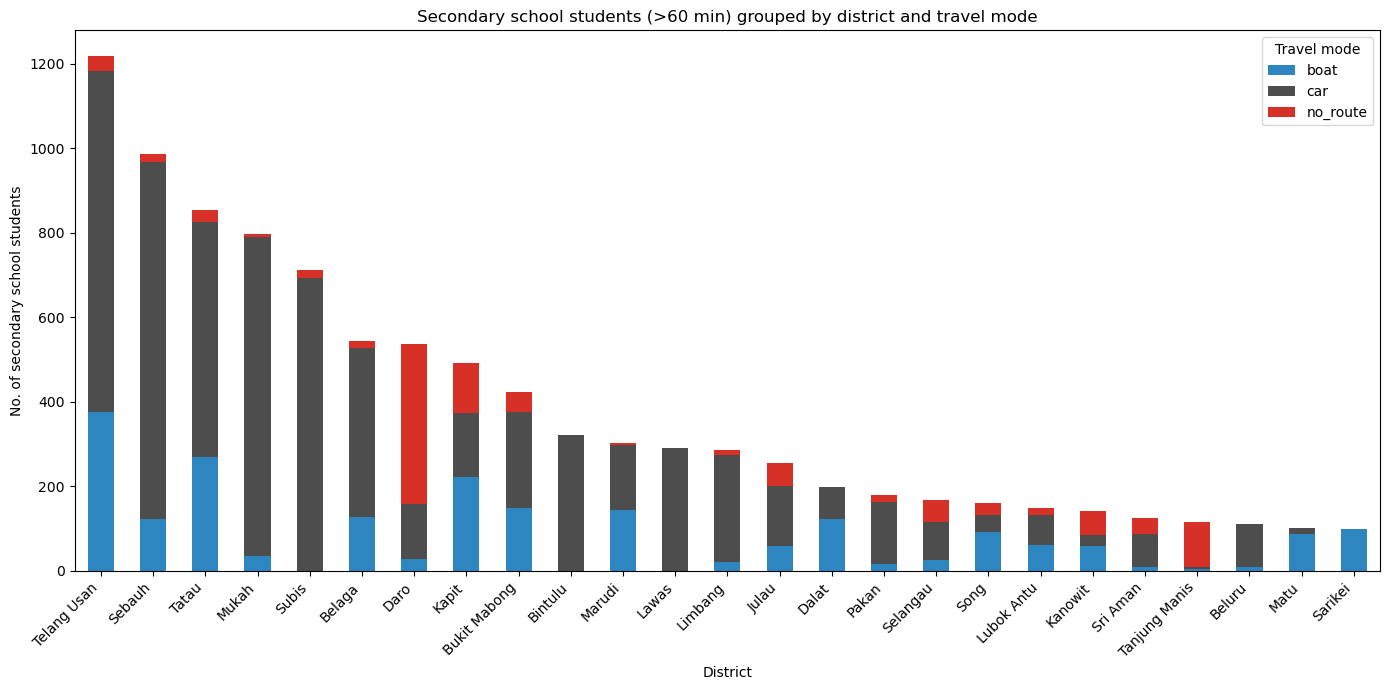

In [18]:
df = secondary_pop_routes_gdf_f.copy()

# --- Aggregate: sum of students by district and travel mode ---
agg = (
    df.groupby(["district", "travel_mode"], dropna=False)["secondary_school_students"]
      .sum()
      .reset_index()
)

# Pivot to wide for stacked bars
pivot = agg.pivot_table(
    index="district",
    columns="travel_mode",
    values="secondary_school_students",
    aggfunc="sum",
    fill_value=0
)

# Optional: keep only top N districts
TOP_N = 25
pivot["__total__"] = pivot.sum(axis=1)
pivot = pivot.sort_values("__total__", ascending=False)
if TOP_N is not None:
    pivot = pivot.head(TOP_N)
pivot = pivot.drop(columns="__total__")

# --- Colour palette (easy to tweak) ---
travel_mode_colors = {
    "no_route": "#d73027",   # softer brick red
    "car": "#4D4D4D",        # softer grey
    "boat": "#2E86C1",       # lighter blue
}

# Ensure colours follow column order
colors = [travel_mode_colors.get(col, "#B0B0B0") for col in pivot.columns]

# --- Plot ---
ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    color=colors
)

ax.set_xlabel("District")
ax.set_ylabel("No. of secondary school students")
ax.set_title("Secondary school students (>60 min) grouped by district and travel mode")
ax.legend(title="Travel mode", loc="best")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
